In [372]:
## Parallel programming imports
import ipyparallel as ipp
from mpi4py import MPI
cluster = ipp.Cluster(engines = "mpi", n = 5)
rc = cluster.start_and_connect_sync()

Starting 5 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/5 [00:00<?, ?engine/s]

In [373]:
%%px

import importlib.util

if importlib.util.find_spec("petsc4py") is not None:
    import dolfinx

    if not dolfinx.has_petsc:
        print("This demo requires DOLFINx to be compiled with PETSc enabled.")
        exit(0)
    from petsc4py.PETSc import ScalarType  # type: ignore
else:
    print("This demo requires petsc4py.")
    exit(0)

# +
import sys
import time

import numpy as np
import petsc4py
from petsc4py import PETSc
import gmsh
import matplotlib.pyplot as plt
import pyvista


import ufl
from ufl import (FacetNormal, Measure, SpatialCoordinate, TestFunction, TrialFunction, 
                 div, dot, dx, grad, inner, lhs, rhs, system)

from dolfinx import fem, io, mesh, plot, la
from dolfinx.fem import (Constant,  Function, functionspace, assemble_scalar, 
                         dirichletbc, form, locate_dofs_topological, Function)
import dolfinx.fem.petsc as petsc
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import (gmshio, XDMFFile, VTXWriter)
from dolfinx.plot import vtk_mesh
from dolfinx.geometry import bb_tree, compute_colliding_cells, compute_collisions_points
from dolfinx.mesh import create_unit_square, locate_entities, meshtags
from dolfinx.graph import partitioner_scotch

petsc4py.init(sys.argv)

In [374]:
%%px

#######################################################################################
# define global parameters here 
time_smoothing = 100.0
n_layers_lumped = 10/1 # 10mm of new lumped layer; 0.05mm per true layer 
delta_t = 0.1 # [s] 

# Define the problem parameters
rho = 4700.0 #[kg/m^3]
cp = 500.0 #[J/(kg*K)]
k = 20.0 #[W/(m*K)]

h_bulk_powder = 10.0 # [W/(m^2*K)]

T_heatplate = 500.0 # [K]
q_powder = h_bulk_powder * 300.0 # [W/m^2] where 300 is the temperature difference between powder and part

T_initial = 600.0 # [K]

# machine parameters 
v_laser = 1.0 # [m/s] https://www.sciencedirect.com/science/article/pii/S2238785424027923
P_laser = 250.0 # [W]
h_hatch_um = 100.0 # [um]
t_interlayer = 10.0 # [s]

x_probe = np.array([[0.05, 0.05, 0.01]]) # where to probe the temperature

#######################################################################################
# intermediate values 
h_hatch = h_hatch_um * 1e-6 # [m]
n_hatches = 0.1/h_hatch 
length_hatch = 0.1 # [m]
t_true = n_hatches * length_hatch / v_laser # [s]
ved = P_laser/(v_laser * h_hatch * t_true)

t_true_scanning = 0.1**2 / (h_hatch * v_laser) # [s]
E_tot_layer = P_laser * t_true_scanning # [J] 
E_tot = n_layers_lumped * E_tot_layer # [J]
t_tot = n_layers_lumped * (t_true + t_interlayer) # [s]
t_per_layer = t_true_scanning + t_interlayer # [s]

# important values: 
q_laserpower = time_smoothing * P_laser / 0.1**2 # [W/m^2]
t_adapt_scanning = t_true_scanning / time_smoothing # [s]

t = 0.0
t_end = n_layers_lumped * t_per_layer # [s]
n_timesteps = int(t_end/delta_t)

# short stability value 
stability_value = delta_t * k / (rho * cp * (0.1/40))

# print some values
print("Stability value: ", stability_value, "; is small?")
print("Total time: ", t_end, "s")
print("Laser applied for ", t_adapt_scanning / delta_t, " time steps")
print("Number of lumped layers: ", n_layers_lumped)

[stdout:2] Stability value:  0.00034042553191489364 ; is small?
Total time:  1100.0000000000002 s
Laser applied for  10.000000000000002  time steps
Number of lumped layers:  10.0


[stdout:0] Stability value:  0.00034042553191489364 ; is small?
Total time:  1100.0000000000002 s
Laser applied for  10.000000000000002  time steps
Number of lumped layers:  10.0


[stdout:1] Stability value:  0.00034042553191489364 ; is small?
Total time:  1100.0000000000002 s
Laser applied for  10.000000000000002  time steps
Number of lumped layers:  10.0


In [375]:
%%px

list_geofiles = [
    "../BoxMeshes/BoxMesh_Layer0.geo",
    "../BoxMeshes/BoxMesh_Layer1.geo",
    "../BoxMeshes/BoxMesh_Layer2.geo",
    "../BoxMeshes/BoxMesh_Layer3.geo"
]

gmsh.initialize()

top_marker, bottom_marker, sides_marker = 13, 14, 15

[stderr:0] Warning : Gmsh has aleady been initialized


[stderr:1] Warning : Gmsh has aleady been initialized


[stderr:2] Warning : Gmsh has aleady been initialized


In [376]:
%%px

def create_mesh_from_geo(layer_): 
    file_name_ = list_geofiles[layer_]
    gmsh.open(file_name_)
    model = gmsh.model
    model_name = model.getCurrent()
    mesh_, cell_tags, facet_tags_ = gmshio.model_to_mesh( 
        model, 
        MPI.COMM_WORLD, 
        rank = 0,
        gdim = 3, 
        partitioner = dolfinx.mesh.create_cell_partitioner(mesh.GhostMode.shared_facet) 
    )
    mesh_.topology.create_connectivity(mesh_.topology.dim-1, mesh_.topology.dim)
    print(len(cell_tags.values), "DOFs for this process")

    return mesh_, cell_tags, facet_tags_

#mesh1, cell_tags1, facet_tags1 = create_mesh_from_geo(0)




%%px
# from Jokken's tutorial: https://jsdokken.com/dolfinx-tutorial/chapter3/robin_neumann_dirichlet.html 
# 1: sides  
# 2: heatplate 
# 3: laser 
boundaries = [(sides_marker, lambda x: np.isclose(x[0], 0.0) | np.isclose(x[0], 1.0) | np.isclose(x[1], 0.0) | np.isclose(x[1], 1.0)),
              (bottom_marker, lambda x: np.isclose(x[2], 0.0)),
              (top_marker, lambda x: np.isclose(x[2], z_max))]

facet_indices, facet_markers = [], []
fdim = umesh.topology.dim - 1
for (marker, locator) in boundaries:
    facets = locate_entities(msh, fdim, locator)
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32)
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(msh, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets])

%%px 
def q_laser_function(t): 
    cycle_index = int(t // t_per_layer)

    if cycle_index >= n_layers_lumped: 
        return q_powder*delta_t
    
    t_in_cycle = t % t_per_layer

    if t_in_cycle < t_adapt_scanning: 
        return -q_laserpower*delta_t
    else: return q_powder*delta_t

def q_powder_function(t): 
    return q_powder*delta_t


In [377]:
%%px

def initialize_weakform(mesh_): 
    V_ = fem.functionspace(mesh_, ("Lagrange", 1))
    T_n_ = Function(V_) # previous time step

    return V_, T_n_

#V1, T_n1 = initialize_weakform(mesh1)
#T_n1.x.array[:] = T_initial

def setup_weakform(mesh_, V_, T_n_, facet_tags_): 
    #V_ = fem.functionspace(mesh_, ("Lagrange", 1))
    ds_ = Measure("ds", domain=mesh_, subdomain_data=facet_tags_)

    # Define the test function and trial function
    T_ = TrialFunction(V_)
    v_ = TestFunction(V_)
    #T_n_ = Function(V_) # previous time step
    x_ = SpatialCoordinate(mesh_)

    # Define the variational form
    a_ = rho * cp * T_ * v_ * dx + delta_t * k * inner(grad(T_), grad(v_)) * dx
    L_laser_ = rho * cp * T_n_ * v_ * dx - inner((q_powder*delta_t), v_) * ds_(sides_marker) - inner((-q_laserpower*delta_t), v_) * ds_(top_marker)
    L_cooling_ = rho * cp * T_n_ * v_ * dx - inner((q_powder*delta_t), v_) * ds_(sides_marker) - inner((q_powder*delta_t), v_) * ds_(top_marker)

    return a_, L_laser_, L_cooling_ 

#a1, L_laser1, L_cooling1 = setup_weakform(mesh1, V1, T_n1, facet_tags1) 


%%px

# We can now create a general boundary condition class.
class BoundaryCondition():
    def __init__(self, type, V_, v_, ds_, facet_tags_, marker, values):
        self._type = type
        if type == "Dirichlet":
            u_D = Function(V_)
            #u_D.interpolate(values)
            u_D.x.array[:] = values  # Assign the provided values to the function
            facets = facet_tags_.find(marker)
            dofs = locate_dofs_topological(V_, fdim, facets)
            self._bc = dirichletbc(u_D, dofs)
        elif type == "Neumann":
            self._bc = inner(values, v_) * ds_(marker)
        elif type == "Robin":
            self._bc = values[0] * inner(T-values[1], v_)* ds_(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))
    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [378]:
%%px 

def create_boundary_conditions(mesh_, V_, facet_tags_): 
    u_D_ = Function(V_)
    u_D_.x.array[:] = T_heatplate 
    facets_ = facet_tags_.find(bottom_marker)
    dofs_ = locate_dofs_topological(V_, mesh_.topology.dim - 1, facets_)
    bcs_ = [dirichletbc(u_D_, dofs_)] # needs to be a list

    return bcs_

#bcs1 = create_boundary_conditions(mesh1, V1, facet_tags1)


%%px

# set BCs initially: 
boundary_conditions1 = [BoundaryCondition("Neumann", V1, v1, ds1, ufacet_tags, sides_marker, q_powder_function(t)), # sides; goes into L 
                       BoundaryCondition("Dirichlet", V1, v1, ds1, ufacet_tags, bottom_marker, T_heatplate), # heatplate 
                       BoundaryCondition("Neumann", V1, v1, ds1, ufacet_tags, top_marker, q_laser_function(t)) # laser; goes into L 
                       ]

boundary_conditions2 = [BoundaryCondition("Neumann", V2, v2, ds2, u2facet_tags, sides_marker, q_powder_function(t)), # sides; goes into L
                       BoundaryCondition("Dirichlet", V2, v2, ds2, u2facet_tags, bottom_marker, T_heatplate), # heatplate
                       BoundaryCondition("Neumann", V2, v2, ds2, u2facet_tags, top_marker, q_laser_function(t)) # laser; goes into L
                       ]

def set_bcs(boundary_conditions, F_list_): 
    bcs_ = []
    for condition in boundary_conditions:
        if condition.type == "Dirichlet":
            bcs_.append(condition.bc)
        else:
            F_list_.append(condition.bc)
    return bcs_, F_list_

# function for only Dirichlet BCs: OBSOLETE?!
def set_dirichlet_bcs(boundary_conds, t):
    bcs_ = []
    for bc_ in boundary_conds:
        if bc_.type == "Dirichlet":
            bcs_.append(bc_.bc)
    return bcs_


bcs1, F_list1 = set_bcs(boundary_conditions1, F_list1)
bcs2, F_list2 = set_bcs(boundary_conditions2, F_list2)

In [379]:
%%px 

# assemble the system
def setup_system(F_laser_, F_cooling_): #--> not needed anymore if a and L_laser and L_cooling are used
    a_laser_, L_laser_ = system(F_laser_)
    a_cooling_, L_cooling_ = system(F_cooling_)
    return a_laser_, L_laser_, a_cooling_, L_cooling_

#a_laser1, L_laser1, a_cooling1, L_cooling1 = setup_system(F_laser1, F_cooling1)
#a_laser2, L_laser2, a_cooling2, L_cooling2 = setup_system(F_laser2, F_cooling2)


def compile_system(a_, L_laser_, L_cooling_, V_, bcs_): 
    compiled_a_ = fem.form(a_)
    A_ = petsc.assemble_matrix(compiled_a_, bcs=bcs_)
    A_.assemble()
    compiled_L_laser_ = fem.form(L_laser_)
    compiled_L_cooling_ = fem.form(L_cooling_)
    return A_, compiled_a_, compiled_L_laser_, compiled_L_cooling_

#A1, compiled_a1, compiled_L_laser1, compiled_L_cooling1 = compile_system(a1, L_laser1, L_cooling1, V1, bcs1)

def setup_solver(mesh_, A_): 
    solver_ = PETSc.KSP().create(mesh_.comm)
    solver_.setOperators(A_)
    solver_.setType("cg")
    pc_ = solver_.getPC()
    pc_.setType("jacobi")

    return solver_

#solver1 = setup_solver(mesh1, A1)

In [380]:
%%px

def get_ranks_containing_probingpoint(mesh_): 
    # Find which cell contains the point (do this only once if the mesh is static)
    tree_ = bb_tree(mesh_, mesh_.topology.dim)
    candidates_ = compute_collisions_points(tree_, x_probe)
    colliding_cells_ = compute_colliding_cells(mesh_, candidates_, x_probe)
    cell_ids_ = colliding_cells_.array

    rank_ = MPI.COMM_WORLD.Get_rank()

    if len(cell_ids_) > 0:
        cell_id_ = cell_ids_[0]  # Get the first (and only) cell ID
        owns_it_ = True # true on only one rank 
    else: 
        owns_it_ = False
        cell_id_ = None

    local_rank_value_ = rank_ if owns_it_ else MPI.COMM_WORLD.Get_size()

    owning_rank_ = MPI.COMM_WORLD.allreduce(local_rank_value_, op=MPI.MIN)

    if owning_rank_ < MPI.COMM_WORLD.Get_size():
        rank_contains_cellid_ = rank_ if rank_ == owning_rank_ else None
        rank_contains_cellid_ = MPI.COMM_WORLD.bcast(rank_contains_cellid_, root=owning_rank_)
    else:
        rank_contains_cellid_ = None  # Nobody owns the cell

    return rank_contains_cellid_, cell_id_

#rank_contains_cellid1, cell_id1 = get_ranks_containing_probingpoint(mesh1)


In [381]:
%%px

##########################################################
# main simulation loop 

def apply_thermal_to_mesh(V_, bcs_, compiled_a_, compiled_L_laser_, compiled_L_cooling_, T_n_, rank_contains_cellid_, cell_id_, solver_): 
    Tracker_Temperature = np.empty(n_timesteps)
    Tracker_time = np.empty(n_timesteps)
    t = 0.0 
    n_i = 0 

    start_time = time.time()

    compiled_L_ = compiled_L_laser_ # start with laser power
    b_ = Function(V_)
    uh_ = Function(V_)

    while t < t_end:
        t += delta_t
        Tracker_time[n_i] = t

        t_in_cycle = t % t_per_layer
        t_in_cycle_earlier = (t - delta_t) % t_per_layer

        if (int(t // t_per_layer) < n_layers_lumped):
            if (t_in_cycle < t_adapt_scanning):
                compiled_L_ = compiled_L_laser_  # laser power
            else: 
                compiled_L_ = compiled_L_cooling_
        else: 
            compiled_L_ = compiled_L_cooling_ 

        # assemble RHS 
        b_.x.array[:] = 0.0
        petsc.assemble_vector(b_.x.petsc_vec, compiled_L_)

        # apply BCs 
        petsc.apply_lifting(b_.x.petsc_vec, [compiled_a_], [bcs_])
        b_.x.scatter_reverse(la.InsertMode.add)
        fem.petsc.set_bc(b_.x.petsc_vec, bcs_)

        # Solve linear problem
        solver_.solve(b_.x.petsc_vec, uh_.x.petsc_vec)
        uh_.x.scatter_forward()

        # Update Tn
        T_n_.x.array[:] = uh_.x.array

        #print temperature at point on side face at z=0.1: 
        if rank_contains_cellid_ == MPI.COMM_WORLD.Get_rank():
            value = uh_.eval(x_probe, cell_id_)
            Tracker_Temperature[n_i] = value[0]
            if n_i % 1 == 0:
                print(f"Time {t:.6f} s: T({x_probe}) = {value[0]:.3f} K")
        
        n_i += 1

    end_time = time.time()
    print("It took", end_time - start_time, "s to solve the problem.")

    # send list to all ranks 
    Tracker_Temperature[:] = MPI.COMM_WORLD.bcast(Tracker_Temperature[:], root=rank_contains_cellid_)

    return Tracker_Temperature, Tracker_time, T_n_


In [382]:
%%px
 
def fill_zeros_with_initial(T_n_: Function, T_initial: float):
    values = T_n_.x.array
    zero_mask = np.isclose(values, 0.0)
    values[zero_mask] = T_initial
    T_n_.x.array[:] = values


def interpolate_to_next_mesh(T_n_from, T_n_to, cell_tags_mesh_to, V_from, V_to):
    all_cells = np.arange(0, len(cell_tags_mesh_to.values)) # roughly 3x faster (0.2ms vs 0.6ms) than locate_entities(umesh, tdim, lambda x:np.full(x.shape[1],True,dtype=bool))
    interpolation_data = dolfinx.fem.create_interpolation_data(V_to, V_from, all_cells)
    T_n_to.interpolate_nonmatching(T_n_from, all_cells, interpolation_data) # None --> all cells are interpolated
    fill_zeros_with_initial(T_n_to, T_initial)
    T_n_to.x.scatter_forward()


In [383]:
%%px 
def setup_firstlayer(): 
    mesh, cell_tags, facet_tags = create_mesh_from_geo(0)
    V, T_n = initialize_weakform(mesh)
    T_n.x.array[:] = T_initial 

    return mesh, cell_tags, facet_tags, V, T_n


def setup_layer(layer_, V, T_n): 
    mesh2, cell_tags2, facet_tags2 = create_mesh_from_geo(layer_)
    V2, T_n2 = initialize_weakform(mesh2)
    interpolate_to_next_mesh(T_n, T_n2, cell_tags2, V, V2)
    V = V2
    T_n = T_n2 
    mesh, cell_tags, facet_tags = mesh2, cell_tags2, facet_tags2 

    return mesh, cell_tags, facet_tags, V, T_n
    
def initialize_layer(mesh, facet_tags, V, T_n):
    a, L_laser, L_cooling = setup_weakform(mesh, V, T_n, facet_tags) 
    bcs = create_boundary_conditions(mesh, V, facet_tags)
    A, compiled_a, compiled_L_laser, compiled_L_cooling = compile_system(a, L_laser, L_cooling, V, bcs)
    solver = setup_solver(mesh, A)
    rank_contains_cellid, cell_id = get_ranks_containing_probingpoint(mesh)

    return a, L_laser, L_cooling, bcs, A, compiled_a, compiled_L_laser, compiled_L_cooling, solver, rank_contains_cellid, cell_id


In [384]:
%%px 
# post-processing 

def gather_trackers(list_Tracker_time, list_Tracker_Temperature):
    total_steps = sum(len(arr) for arr in list_Tracker_time)
    Tracker_time = np.empty(total_steps)
    Tracker_Temperature = np.empty(total_steps)

    # Concatenate the results from all layers
    for i in range(len(list_Tracker_time)):
        start_index = sum(len(arr) for arr in list_Tracker_time[:i])
        end_index = start_index + len(list_Tracker_time[i])
        Tracker_time[start_index:end_index] = list_Tracker_time[i]
        Tracker_Temperature[start_index:end_index] = list_Tracker_Temperature[i]

def process_trackers(list_Tracker_time, list_Tracker_Temperature):
    Tracker_time = []
    Tracker_Temperature = []
    offset_time = 0

    for arr in list_Tracker_time:
        adjusted = arr + offset_time
        Tracker_time.append(adjusted)
        offset_time = adjusted[-2]  # last value becomes the new offset

    for arr in list_Tracker_Temperature:
        Tracker_Temperature.append(arr)

    Tracker_time = np.concatenate(Tracker_time) 
    Tracker_Temperature = np.concatenate(Tracker_Temperature)
    Tracker_derivative = np.gradient(Tracker_Temperature, Tracker_time)

    return Tracker_time, Tracker_Temperature, Tracker_derivative

Tracker_time, Tracker_Temperature, Tracker_derivative = process_trackers(copy_list_Tracker_time, copy_list_Tracker_Temperature)


In [385]:
%%px 

def run_simulation():
    start_time = time.time()

    list_Tracker_time = []
    list_Tracker_Temperature = []

    for layer, filename in enumerate(list_geofiles):
        if layer == 0: 
            mesh, cell_tags, facet_tags, V, T_n = setup_firstlayer()
        else: 
            mesh, cell_tags, facet_tags, V, T_n = setup_layer(layer, V, T_n)
        a, L_laser, L_cooling, bcs, A, compiled_a, compiled_L_laser, compiled_L_cooling, solver, rank_contains_cellid, cell_id = initialize_layer(mesh, facet_tags, V, T_n)
        print("Layer ", layer, " initialized")

        Tracker_Temperature, Tracker_time, T_n = apply_thermal_to_mesh(V, bcs, compiled_a, compiled_L_laser, compiled_L_cooling, T_n, rank_contains_cellid, cell_id, solver)
        
        list_Tracker_time.append(Tracker_time)
        list_Tracker_Temperature.append(Tracker_Temperature)

    end_time = time.time()
    print("Total simulation time: ", end_time - start_time, "s")

    return list_Tracker_time, list_Tracker_Temperature

list_Tracker_time, list_Tracker_Temperature = run_simulation()

[stderr:2] Warning : Boolean fragments skipped - too few arguments


[stdout:2] 6760 DOFs for this process
Layer  0  initialized
It took 13.023324251174927 s to solve the problem.
14455 DOFs for this process
Layer  1  initialized
It took 20.664180040359497 s to solve the problem.
22039 DOFs for this process
Layer  2  initialized
It took 30.91321349143982 s to solve the problem.
28927 DOFs for this process
Layer  3  initialized
It took 43.0460889339447 s to solve the problem.
Total simulation time:  109.6320116519928 s


[stderr:0] Warning : Boolean fragments skipped - too few arguments


[stdout:0] 6796 DOFs for this process
Layer  0  initialized
It took 13.023303031921387 s to solve the problem.
14347 DOFs for this process
Layer  1  initialized
It took 20.664170265197754 s to solve the problem.
21659 DOFs for this process
Layer  2  initialized
Time 0.100000 s: T([[0.05 0.05 0.01]]) = 498.553 K
Time 0.200000 s: T([[0.05 0.05 0.01]]) = 498.554 K
Time 0.300000 s: T([[0.05 0.05 0.01]]) = 498.564 K
Time 0.400000 s: T([[0.05 0.05 0.01]]) = 498.589 K
Time 0.500000 s: T([[0.05 0.05 0.01]]) = 498.638 K
Time 0.600000 s: T([[0.05 0.05 0.01]]) = 498.717 K
Time 0.700000 s: T([[0.05 0.05 0.01]]) = 498.832 K
Time 0.800000 s: T([[0.05 0.05 0.01]]) = 498.985 K
Time 0.900000 s: T([[0.05 0.05 0.01]]) = 499.175 K
Time 1.000000 s: T([[0.05 0.05 0.01]]) = 499.400 K
Time 1.100000 s: T([[0.05 0.05 0.01]]) = 499.658 K
Time 1.200000 s: T([[0.05 0.05 0.01]]) = 499.946 K
Time 1.300000 s: T([[0.05 0.05 0.01]]) = 500.260 K
Time 1.400000 s: T([[0.05 0.05 0.01]]) = 500.596 K
Time 1.500000 s: T([[0.0

[stderr:1] Warning : Boolean fragments skipped - too few arguments


%px:   0%|          | 0/3 [00:00<?, ?tasks/s]

[stdout:1] 7067 DOFs for this process
Layer  0  initialized
Time 0.100000 s: T([[0.05 0.05 0.01]]) = 708.921 K
Time 0.200000 s: T([[0.05 0.05 0.01]]) = 769.243 K
Time 0.300000 s: T([[0.05 0.05 0.01]]) = 813.457 K
Time 0.400000 s: T([[0.05 0.05 0.01]]) = 849.875 K
Time 0.500000 s: T([[0.05 0.05 0.01]]) = 881.500 K
Time 0.600000 s: T([[0.05 0.05 0.01]]) = 909.755 K
Time 0.700000 s: T([[0.05 0.05 0.01]]) = 935.449 K
Time 0.800000 s: T([[0.05 0.05 0.01]]) = 959.097 K
Time 0.900000 s: T([[0.05 0.05 0.01]]) = 981.061 K
Time 1.000000 s: T([[0.05 0.05 0.01]]) = 1001.607 K
Time 1.100000 s: T([[0.05 0.05 0.01]]) = 911.891 K
Time 1.200000 s: T([[0.05 0.05 0.01]]) = 869.772 K
Time 1.300000 s: T([[0.05 0.05 0.01]]) = 842.834 K
Time 1.400000 s: T([[0.05 0.05 0.01]]) = 822.838 K
Time 1.500000 s: T([[0.05 0.05 0.01]]) = 806.833 K
Time 1.600000 s: T([[0.05 0.05 0.01]]) = 793.439 K
Time 1.700000 s: T([[0.05 0.05 0.01]]) = 781.892 K
Time 1.800000 s: T([[0.05 0.05 0.01]]) = 771.719 K
Time 1.900000 s: T([[

[output:0]

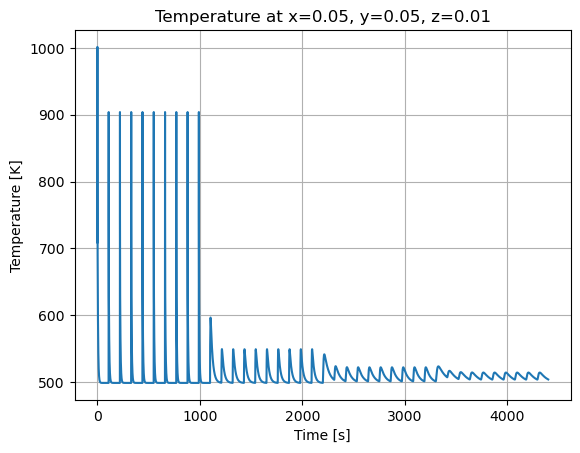

[output:0]

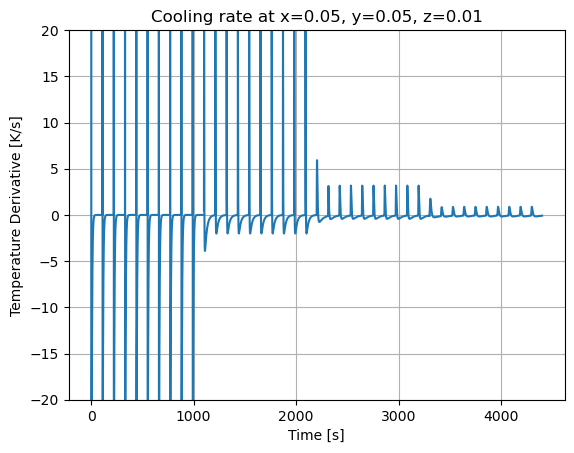

In [386]:
%%px 

if MPI.COMM_WORLD.Get_rank() == 0: # only print on one rank
    plt.figure()
    plt.plot(Tracker_time, Tracker_Temperature)
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [K]")
    plt.title(f"Temperature at x={x_probe[0, 0]}, y={x_probe[0, 1]}, z={x_probe[0, 2]}")
    #plt.xlim(0, 20)
    plt.grid()
    #plt.savefig("output/figs_noprecompileCrankNicolson0201.png")
    plt.show()

    plt.figure()
    plt.plot(Tracker_time, Tracker_derivative)
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature Derivative [K/s]")
    plt.title(f"Cooling rate at x={x_probe[0, 0]}, y={x_probe[0, 1]}, z={x_probe[0, 2]}")
    plt.ylim(-20, 20)
    #plt.xlim(0, 20)
    plt.grid()
    #plt.savefig("output/figsderiv_noprecompileCrankNicolson0201.png")
    plt.show()

[stdout:1] Temperature at t= 2.0 s:  473.6084945782603 °C
derivative at t= 2.0 s:  -72.99414169144666 K/s


[output:1]

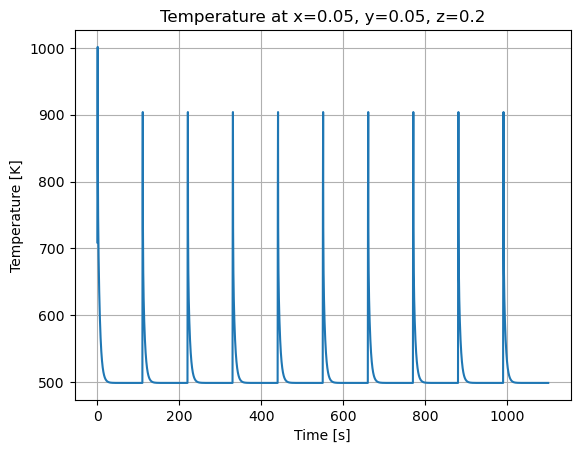

[output:1]

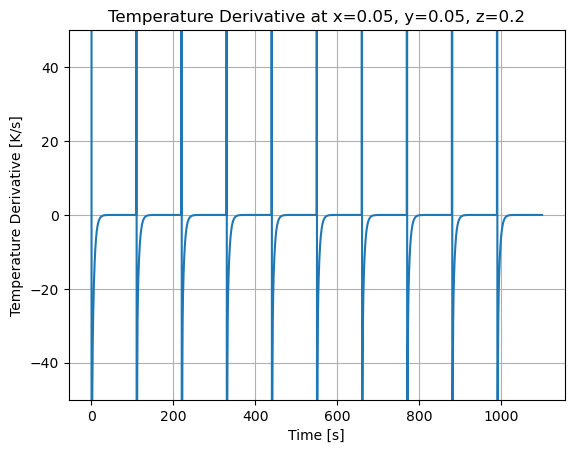

In [21]:
%%px

T_tracker_derivative1 = np.empty(n_timesteps)

if rank_contains_cellid1 == MPI.COMM_WORLD.Get_rank():
    T_tracker_derivative1 = np.gradient(T_tracker1[:n_i], Tracker_time1[:n_i])

    t_checker = 2.0 
    n = int(t_checker / delta_t)
    print("Temperature at t=", n*delta_t, "s: ", T_tracker1[n]-273.15, "°C")
    print("derivative at t=", n*delta_t, "s: ", T_tracker_derivative1[n], "K/s")

    #plot the temperature curve of T_tracker1
    plt.figure()
    plt.plot(Tracker_time1[:n_i], T_tracker1[:n_i])
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature [K]")
    plt.title("Temperature at x=0.05, y=0.05, z=0.2")
    #plt.xlim(0, 20)
    plt.grid()
    #plt.savefig("output/figs_noprecompileCrankNicolson0201.png")
    plt.show()

    plt.figure()
    plt.plot(Tracker_time1[:n_i], T_tracker_derivative1)
    plt.xlabel("Time [s]")
    plt.ylabel("Temperature Derivative [K/s]")
    plt.title("Temperature Derivative at x=0.05, y=0.05, z=0.2")
    plt.ylim(-50, 50)
    #plt.xlim(0, 20)
    plt.grid()
    #plt.savefig("output/figsderiv_noprecompileCrankNicolson0201.png")
    plt.show()

T_tracker_derivative1 = MPI.COMM_WORLD.bcast(T_tracker_derivative1, root=rank_contains_cellid2)


In [287]:
%%px

import pyvista
from dolfinx.plot import vtk_mesh

# Get VTK-compatible mesh and cell type
#grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh1, mesh1.topology.dim))

# Add solution values to the grid
grid.point_data["Temperature"] = T_n.x.array.real

# Plot
plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="Temperature", cmap="coolwarm", show_edges=True)
plotter.add_scalar_bar("Temperature")
plotter.show()


[2:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[280], line 8
      2 from dolfinx.plot import vtk_mesh
      4 # Get VTK-compatible mesh and cell type
      5 #grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh1, mesh1.topology.dim))
      6 
      7 # Add solution values to the grid
----> 8 grid.point_data["Temperature"] = T_n.x.array.real
     10 # Plot
     11 plotter = pyvista.Plotter()

NameError: name 'T_n' is not defined
[0:execute]
---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
Cell In[280], line 8
      2 from dolfinx.plot import vtk_mesh
      4 # Get VTK-compatible mesh and cell type
      5 #grid = pyvista.UnstructuredGrid(*vtk_mesh(mesh1, mesh1.topology.dim))
      6 
      7 # Add solution values to the grid
----> 8 grid.point_data["Temperature"] = T_

AlreadyDisplayedError: 3 errors

In [25]:
%%px

import pyvista
from dolfinx.plot import vtk_mesh

# Get VTK-compatible mesh and cell type
grid = pyvista.UnstructuredGrid(*vtk_mesh(u2mesh, umesh.topology.dim))

# Add solution values to the grid
grid.point_data["Temperature"] = T_n2.x.array.real

# Plot
plotter = pyvista.Plotter()
plotter.add_mesh(grid, scalars="Temperature", cmap="coolwarm", show_edges=True)
plotter.add_scalar_bar("Temperature")
plotter.show()


[output:0]

Widget(value='<iframe src="http://localhost:36855/index.html?ui=P_0x7fe6d9834e10_1&reconnect=auto" class="pyvi…

%px:   0%|          | 0/3 [00:00<?, ?tasks/s]

[output:2]

Widget(value='<iframe src="http://localhost:35249/index.html?ui=P_0x7f80334cce10_1&reconnect=auto" class="pyvi…

[output:1]

Widget(value='<iframe src="http://localhost:42543/index.html?ui=P_0x7fc39bf39a90_1&reconnect=auto" class="pyvi…